# **House Price Prediction**

# 1. Формулировка задачи и цели исследования

Задачей данного исследования является построение регрессионной модели для прогнозирования стоимости жилого дома на основе характеристик объекта недвижимости, представленных в датасете.

Целью исследования является выявление факторов, оказывающих наибольшее влияние на цену дома, а также оценка возможности использования методов машинного обучения для точного и интерпретируемого прогнозирования рыночной стоимости недвижимости.

# 2. Определение метрик и критериев качества

Для оценки качества построенной регрессионной модели используются стандартные метрики регрессии: средняя абсолютная ошибка (MAE), среднеквадратичная ошибка (RMSE) и коэффициент детерминации (R²).

Метрика MAE позволяет оценить среднюю величину отклонения предсказанной стоимости дома от фактической цены и является интуитивно понятной с точки зрения интерпретации. Метрика RMSE более чувствительна к большим ошибкам и используется для оценки устойчивости модели к выбросам. Коэффициент детерминации R² характеризует долю дисперсии целевой переменной, объясняемую моделью, и позволяет оценить общее качество аппроксимации данных.

В качестве критерия успешности модели рассматривается минимизация значений MAE и RMSE, а также достижение максимально возможного значения R² на тестовой выборке.

# 3. Загрузка и первичный обзор данных

Данные взяты с сайта Kaggle

Анализ структуры датасета, типов признаков и общего объёма данных.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prokshitha/home-value-insights")

print("Path to dataset files:", path)

c:\Users\user\ANALYSIS\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\user\.cache\kagglehub\datasets\prokshitha\home-value-insights\versions\1


In [2]:
import pandas as pd

# "C:\Users\user\.cache\kagglehub\datasets\prokshitha\home-value-insights\versions\1\house_price_regression_dataset.csv"

# Use the full path to your data file
file_path = "C:/Users/user/.cache/kagglehub/datasets/prokshitha/home-value-insights/versions/1/house_price_regression_dataset.csv" 

# Read the data into a DataFrame
df_origin = pd.read_csv(file_path)

df = df_origin.copy()
# Посмотрим структуру
df.head(5)

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [3]:
# имена признаков
df.columns

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='str')

In [4]:
# типы данных, пропуски
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


**Первичный анализ данных**

В ходе первичного анализа было установлено, что датасет содержит 1000 наблюдений и 8 признаков. Все признаки представлены числовыми типами данных: шесть признаков имеют целочисленный тип (int64) из них один категориальный - качество района(Neighborhood_Quality), два признака — вещественный тип (float64).

Пропущенные значения в датасете отсутствуют, что свидетельствует о его высокой степени готовности к дальнейшему анализу и построению модели без необходимости дополнительной очистки данных.

Целевая переменная **House_Price** представляет собой вещественное число и отражает стоимость жилого дома. Остальные признаки описывают основные характеристики объекта недвижимости, такие как **площадь дома** (Square_Footage), **количество спален** и **ванных комнат** (Num_Bedrooms, Num_Bathrooms), **год постройки** (Year_Built), **размер земельного участка** (Lot_Size), **наличие гаража** (Garage_Size) и **качество района** (Neighborhood_Quality).

Таким образом, датасет является структурированным, сбалансированным и пригодным для решения задачи регрессии по прогнозированию цены дома.

# 4. Exploratory Data Analysis (EDA):
### 4.1 основные статистики

In [17]:
# основные статистики
df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


**Описание числовых признаков**

Датасет содержит 1000 наблюдений и включает числовые признаки, описывающие основные характеристики жилых домов. Средняя площадь дома составляет около 2800 квадратных футов, при этом минимальное значение — около 500, максимальное — около 5000. В среднем дом имеет 3 спальни и 2 ванные комнаты.

Год постройки домов варьируется от 1950 до 2022, при среднем значении около 1987 года, что указывает на разнообразие как старых, так и относительно новых объектов. Размер земельного участка в среднем составляет около 2.8 условных единиц, а гараж в большинстве случаев рассчитан на 1 автомобиль.

Качество района оценивается по шкале от 1 до 10, со средним значением около 5.6. Средняя цена дома составляет приблизительно 619 тысяч, при этом значения варьируются от 110 тысяч до более чем 1.1 миллиона, что указывает на широкий диапазон цен в датасете.

### 4.2 Анализ целевой перемеменной

In [18]:
# Импортируем библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки для графиков
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 4)

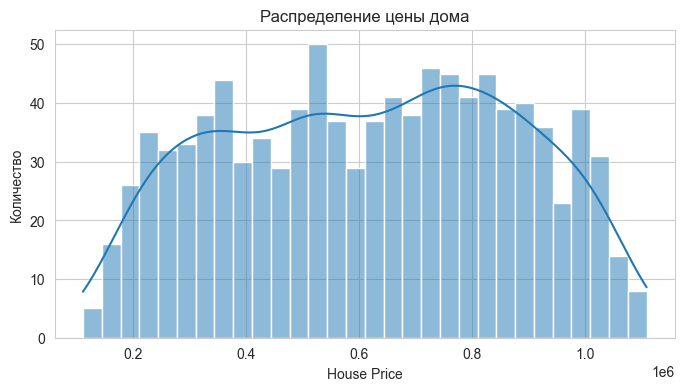

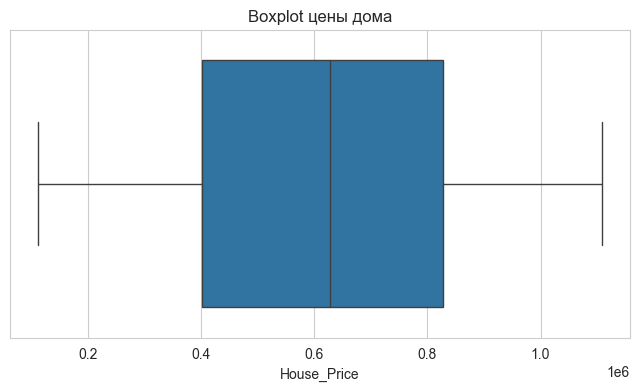

In [19]:
# Анализ целевой переменной
plt.figure()
sns.histplot(df['House_Price'], bins=30, kde=True)
plt.title('Распределение цены дома')
plt.xlabel('House Price')
plt.ylabel('Количество')
plt.show()

plt.figure()
sns.boxplot(x=df['House_Price'])
plt.title('Boxplot цены дома')
plt.show()

**Анализ распределения цены дома**

1. **Форма распределения**

Распределение цен домов примерно равномерное с лёгкой скошенностью вправо — есть несколько домов с высокой ценой, которые немного выбиваются из общей массы.

Это видно по длинному «хвосту» справа на графике.

2. **Центральная тенденция**

Большинство домов сосредоточено в диапазоне $200 000 – $900 000.

Пик количества домов приходится примерно на $500 000 – $800 000.

3. **Выбросы**

Небольшое количество домов с ценой выше $1 000 000 можно считать потенциальными выбросами.

Слева явных выбросов нет, минимальные цены находятся в пределах типичного диапазона.

4. **Выводы для модели**

Модель регрессии должна учитывать правый хвост распределения — возможно, полезно рассмотреть логарифмирование цены, чтобы уменьшить влияние высоких значений на обучение.

В целом данные не сильно скошены и пригодны для построения регрессии, но есть редкие дорогие дома, которые могут повлиять на MAE и RMSE.

### 4.3 Анализ числовых признаков

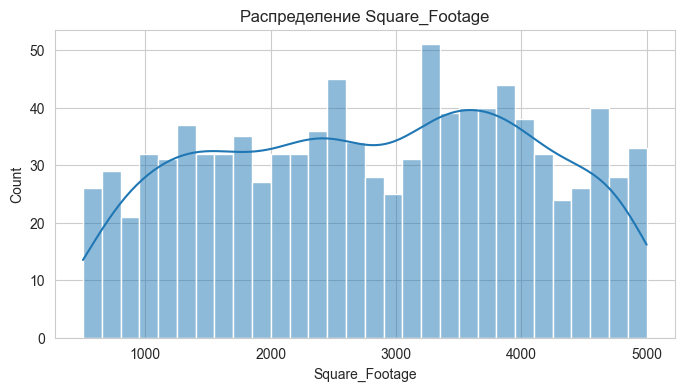

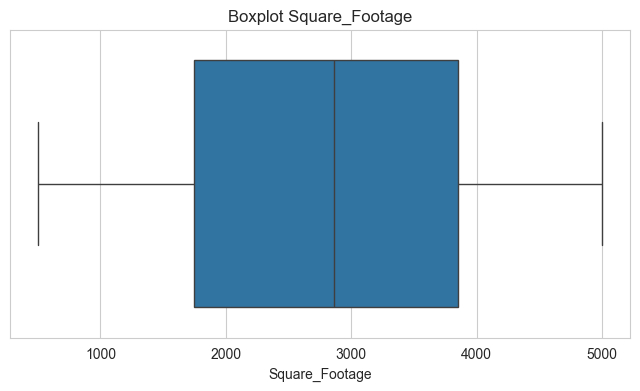

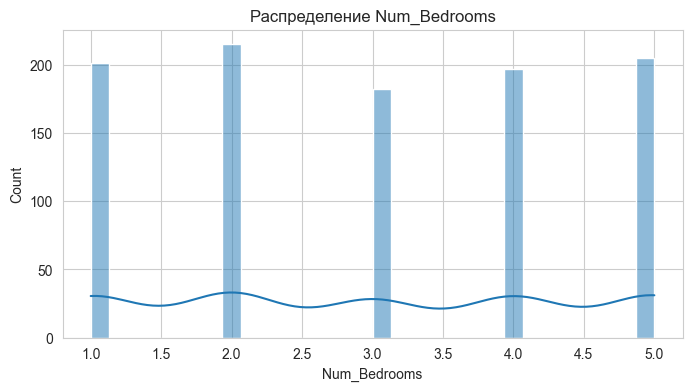

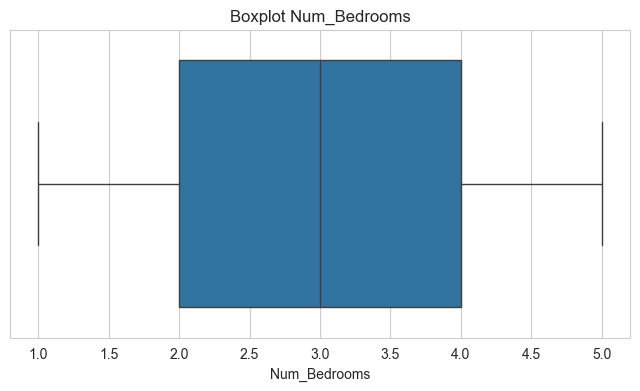

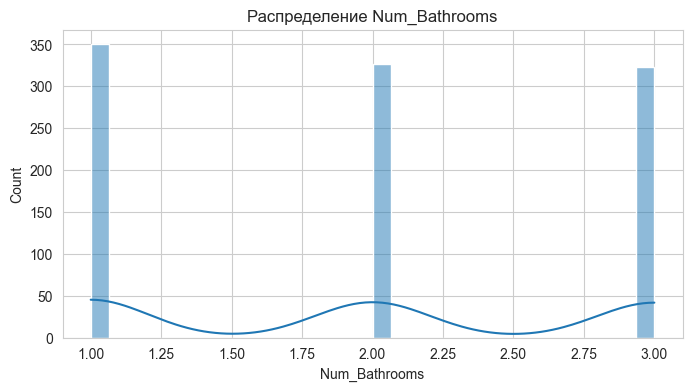

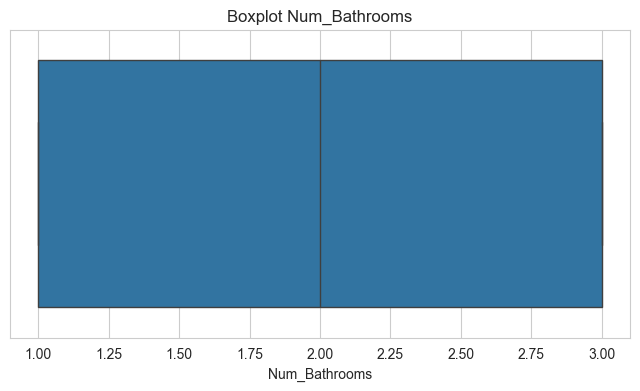

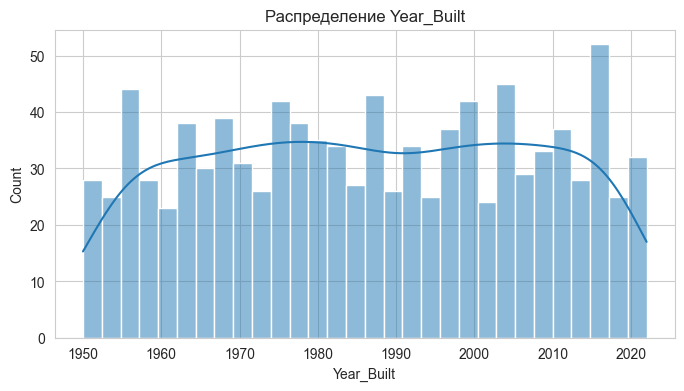

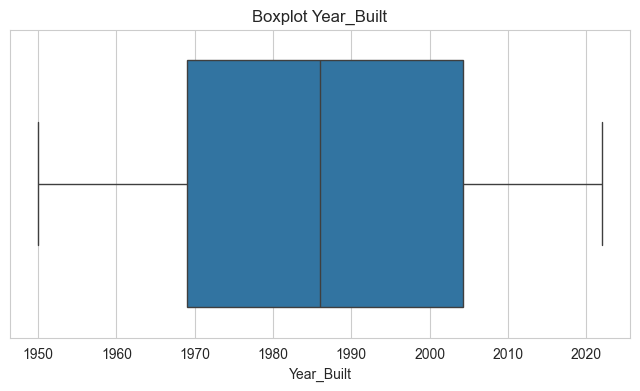

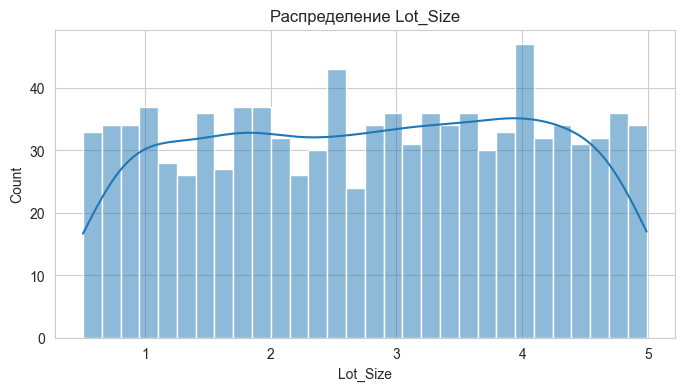

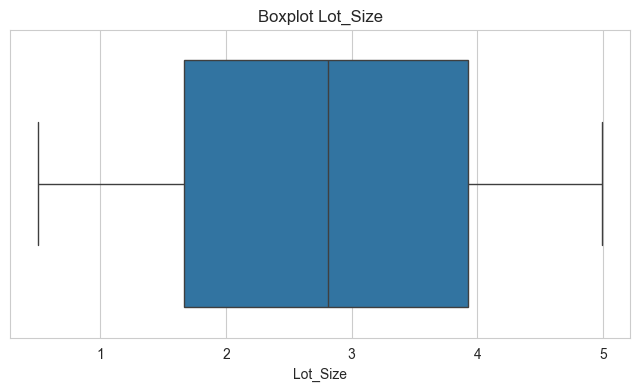

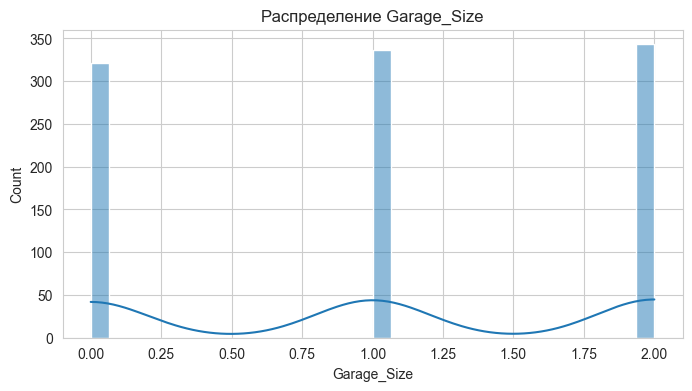

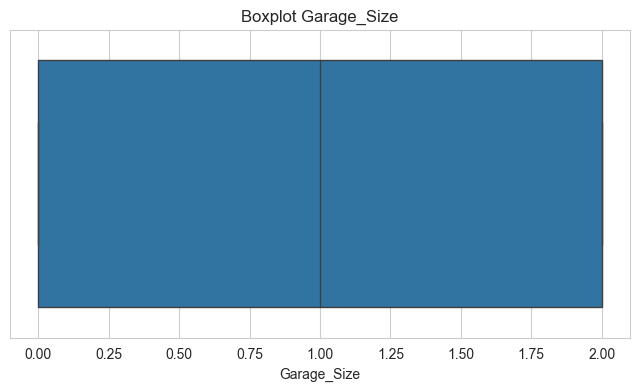

In [20]:

numeric_features = ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 
                    'Year_Built', 'Lot_Size', 'Garage_Size']

for col in numeric_features:
    plt.figure()
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Распределение {col}')
    plt.show()
    
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot {col}')
    plt.show()

### Распределение признаков

**Square_Footage**

График показывает, что площадь домов (Square_Footage) распределена в широком диапазоне — примерно от 500 до 5000 квадратных футов. Основная масса наблюдений сосредоточена в интервале 1500–4000, средняя: 2,815 кв.футов, при этом распределение близко к равномерному без выраженной асимметрии.

Явных выбросов или экстремальных значений не наблюдается, что говорит о хорошем качестве данных. Признак имеет логичное распределение и является потенциально одним из ключевых факторов при прогнозировании цены дома.

**Lot_Size**

График показывает, что значения признака Lot_Size распределены достаточно равномерно в диапазоне примерно от 0.5 до 5. Явной асимметрии или выраженного смещения распределения не наблюдается (медиана 2.81 ≈ среднему 2.78), что указывает на отсутствие сильных перекосов в данных.

Плотность распределения имеет несколько локальных пиков, однако они не носят экстремального характера и не свидетельствуют о наличии выбросов. В целом признак имеет стабильное распределение и может быть напрямую использован в модели без дополнительной трансформации.

**Year_Built**

График показывает, что значения признака распределены достаточно равномерно в диапазоне примерно от 1950 до 2022 (72 года), средний: 1986 год, 50% домов построены: 1969-2004. Явной асимметрии или выраженного смещения распределения не наблюдается, что указывает на отсутствие сильных перекосов в данных. В целом признак имеет стабильное распределение и может быть напрямую использован в модели без дополнительной трансформации.

**Комнаты:**
- **Спальни:** в среднем 3 (медиана 3), диапазон 1-5
- **Ванные:** в среднем 2 (медиана 2), диапазон 1-3
- **Распределение дискретное**, что соответствует реальным данным

**Гараж (Garage_Size):**

В среднем на 1 машину, 25% домов без гаража (Garage_Size = 0), Максимум: на 2 машины


### 4.4 Анализ категориального/рейтингового признака

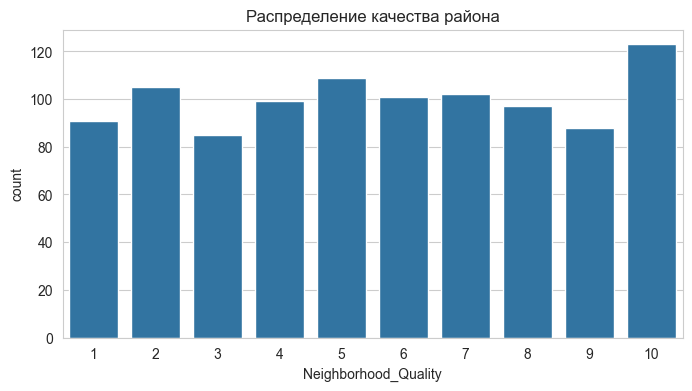

In [21]:
plt.figure()
sns.countplot(x='Neighborhood_Quality', data=df)
plt.title('Распределение качества района')
plt.show()

**Распределение категориального признака Neighborhood_Quality**

График показывает распределение качества района (Neighborhood_Quality), представленного дискретными категориями от 1 до 10. Значения распределены достаточно равномерно, без сильного смещения в сторону отдельных категорий.

Наиболее часто встречаются районы со средним и высоким качеством (5–10), однако различия между категориями не являются критичными. Такое распределение позволяет корректно использовать данный признак в модели без риска перекоса и делает его потенциально информативным для прогнозирования цены дома.

### 4.5 Корреляционный анализ

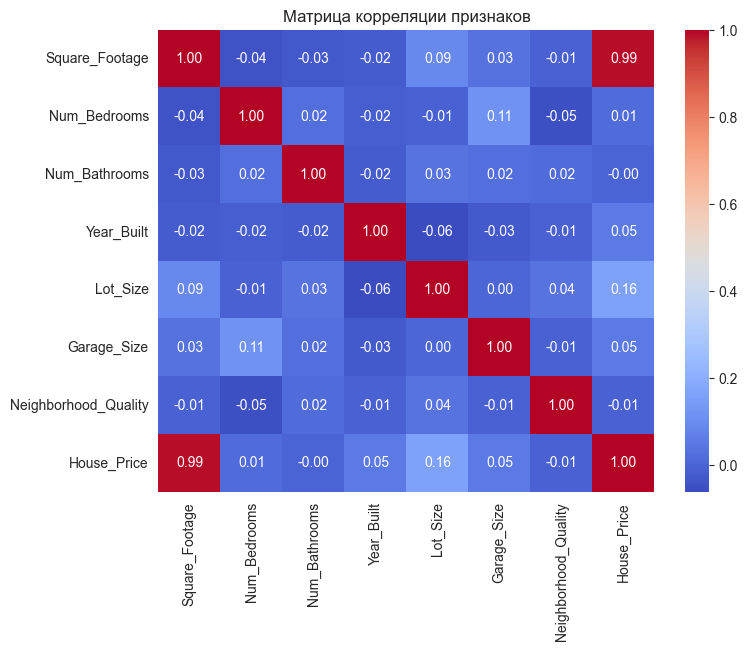

In [22]:
corr = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Матрица корреляции признаков')
plt.show()

In [23]:
df.columns

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='str')

Признак **Square_Footage** демонстрирует сильную положительную линейную связь с целевой переменной, что указывает на его ключевую роль в прогнозировании цены дома. Признаки **Year_Built**, **Lot_Size** и **Garage_Size** имеют слабую положительную корреляцию, тогда как остальные признаки показывают близкую к нулю или отрицательную линейную связь с ценой.

При этом слабая корреляция не означает низкую информативность признака, поскольку его влияние может проявляться в сочетании с другими переменными или в нелинальной форме. Для более детального анализа характера зависимостей и выявления возможных нелинейных эффектов целесообразно дополнительно построить парные графики (pairplot) и диаграммы рассеяния между признаками и целевой переменной.

### 4.6 Scatter plots числовых признаков vs целевой

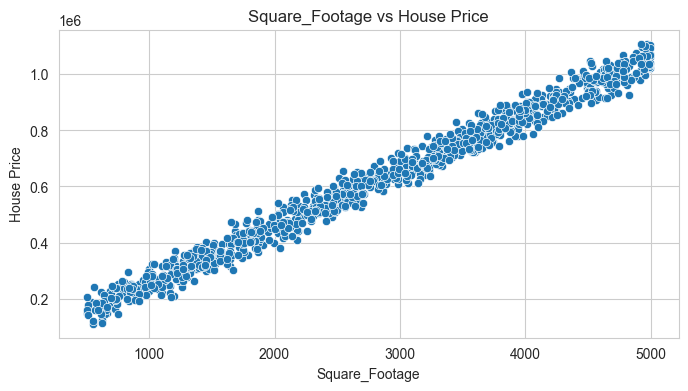

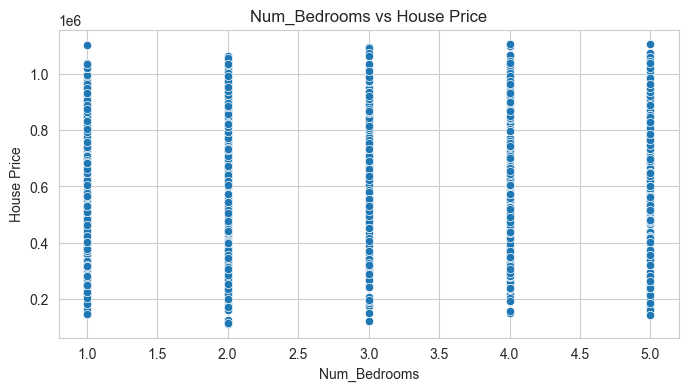

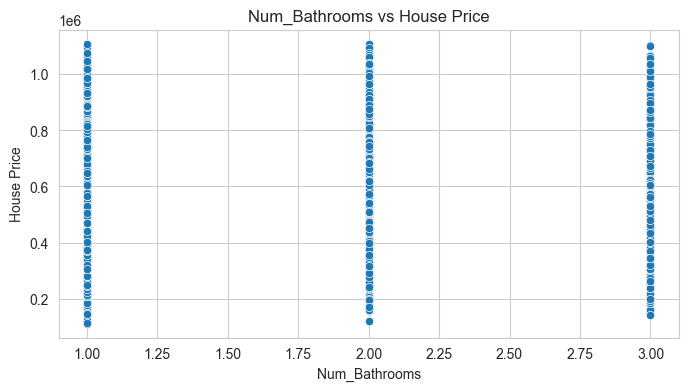

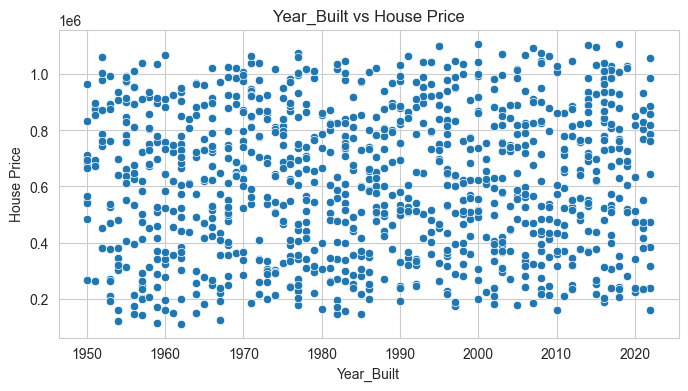

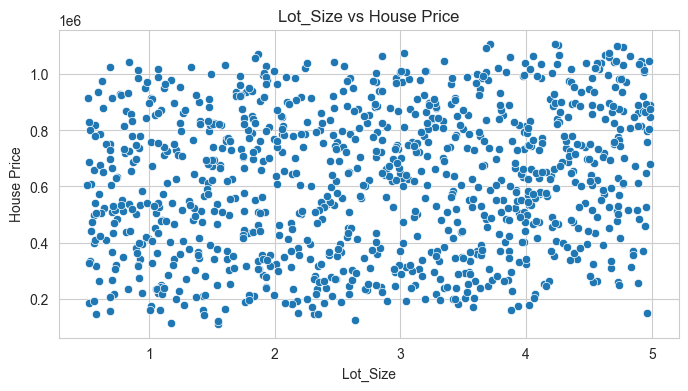

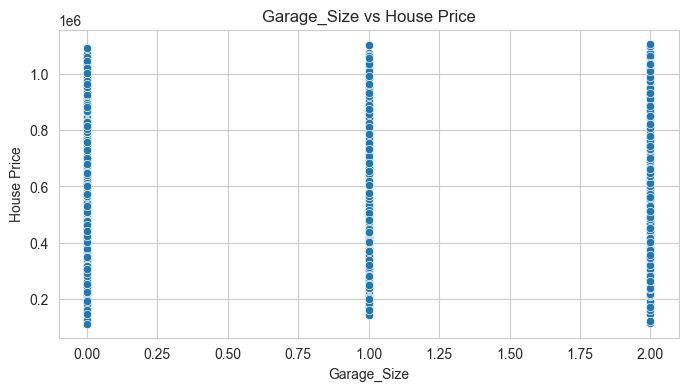

In [24]:
for col in numeric_features:
    plt.figure()
    sns.scatterplot(x=df[col], y=df['House_Price'])
    plt.title(f'{col} vs House Price')
    plt.xlabel(col)
    plt.ylabel('House Price')
    plt.show()

### 4.7 Pairplot для выбора ключевых признаков и проверка выбросов

Признак **Square_Footage** наглядно демонстрирует выраженную положительную линейную зависимость с ценой дома. Для остальных признаков явной линейной зависимости с целевой переменной не наблюдается. В связи с этим, а также с целью исключения влияния взаимосвязей между признаками, необходимо дополнительно проверить данные на наличие мультиколлинеарности между независимыми переменными.

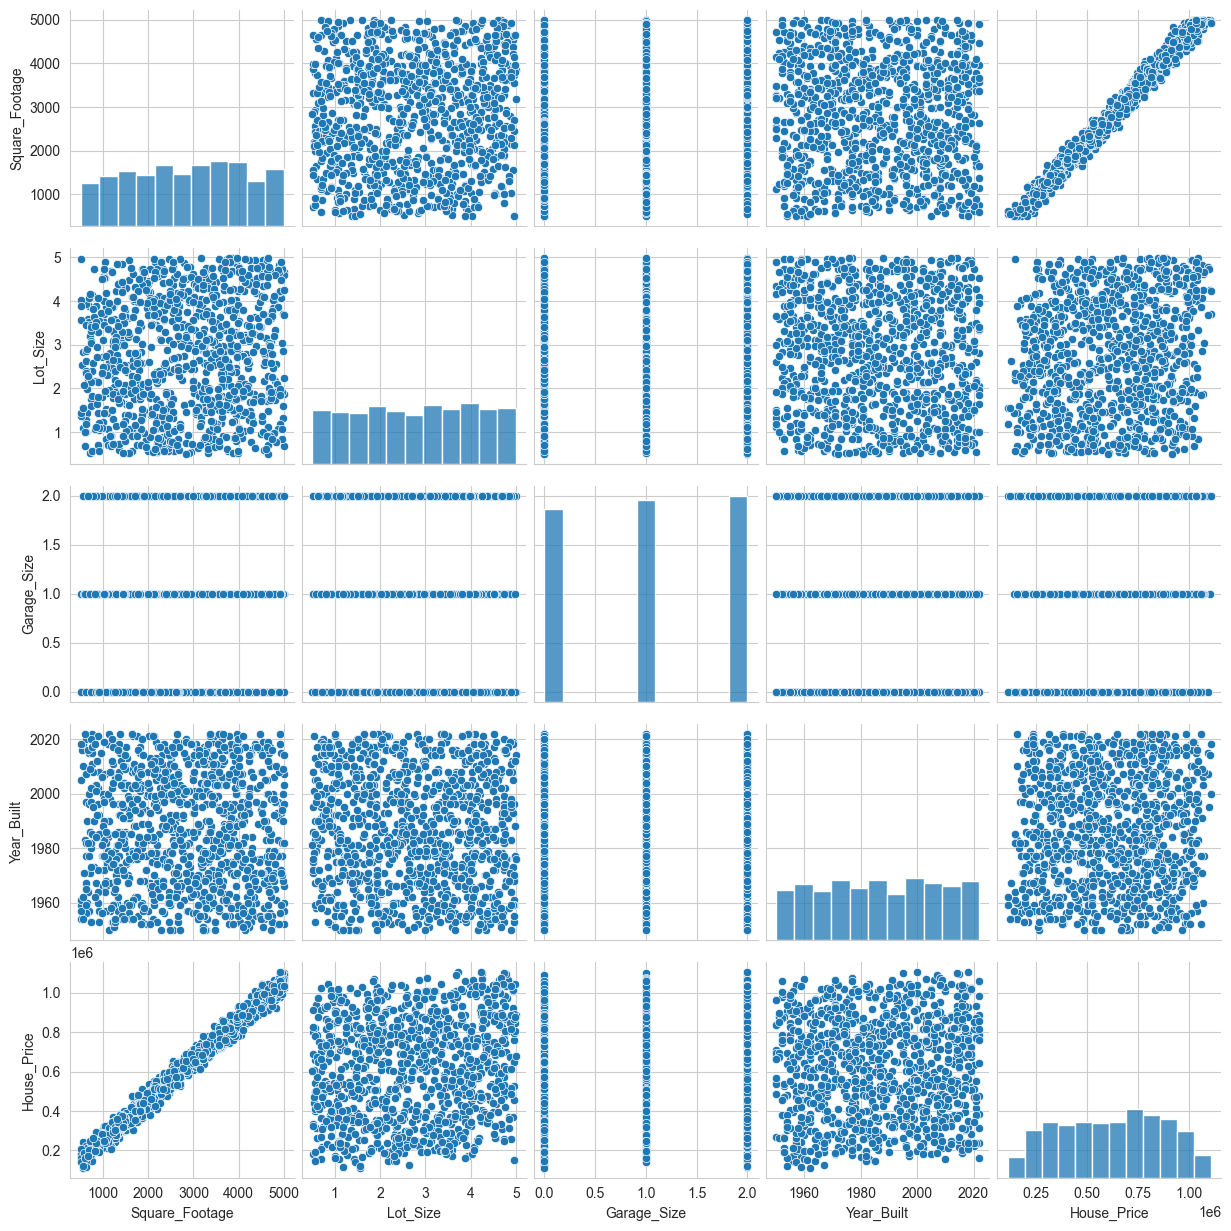

In [25]:
# Ограничим для скорости только 4 наиболее значимых признака (по корреляции с ценой)
top_features = corr['House_Price'].abs().sort_values(ascending=False).index[1:5]
sns.pairplot(df[top_features.tolist() + ['House_Price']])
plt.show()

In [26]:
# Выявление выбросов (z-score)
from scipy.stats import zscore
z_scores = np.abs(zscore(df[numeric_features + ['House_Price']]))
outliers = (z_scores > 3).any(axis=1)
print(f'Количество потенциальных выбросов: {outliers.sum()}')

Количество потенциальных выбросов: 0


Для более детального анализа взаимосвязей между наиболее значимыми признаками и ценой дома был построен pairplot для признаков с наибольшей корреляцией с целевой переменной. Полученные графики подтверждают ранее сделанные выводы: выраженная линейная зависимость наблюдается преимущественно для признака **Square_Footage**, тогда как для остальных признаков явного линейного тренда не выявлено.

Таким образом, визуальный анализ парных распределений не выявил скрытых нелинейных зависимостей и подтверждает результаты корреляционного анализа. В связи с этим дальнейший этап исследования целесообразно сосредоточить на проверке мультиколлинеарности признаков и корректном выборе линейной модели.

Выбросов также не наблюдается, следовательно дополнительны преобразований данных не требуется

### 4.7 Проверка на мультиколлениарность

**Variance Inflation Factor (VIF)**

Самый корректный статистический метод выявления мультиколлинеарности.

Идея:
**VIF** показывает, насколько сильно дисперсия коэффициента увеличивается из-за линейной зависимости с другими признаками.

Как интерпретировать:

VIF ≈ 1 — мультиколлинеарность отсутствует

VIF > 5 — умеренная мультиколлинеарность

VIF > 10 — сильная мультиколлинеарность (признак проблемный)

In [27]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df.drop(columns=['House_Price'])

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) 
                   for i in range(X.shape[1])]

print(vif_data)


                feature        VIF
0        Square_Footage   6.101523
1          Num_Bedrooms   5.483174
2         Num_Bathrooms   6.806133
3            Year_Built  24.704359
4              Lot_Size   5.633428
5           Garage_Size   2.611489
6  Neighborhood_Quality   4.803468


**Анализ мультиколлинеарности (VIF)**

Для выявления линейной взаимосвязи между признаками был рассчитан показатель инфляции дисперсии (Variance Inflation Factor, VIF). Результаты анализа показали наличие мультиколлинеарности между рядом признаков.

Признак Year_Built имеет очень высокое значение VIF (24.7), что свидетельствует о сильной линейной зависимости от других переменных и потенциально может негативно влиять на устойчивость коэффициентов линейной регрессионной модели.

Признаки Square_Footage, Num_Bedrooms, Num_Bathrooms и Lot_Size демонстрируют умеренную мультиколлинеарность (VIF в диапазоне 5–7). Это может быть связано с тем, что данные характеристики описывают размер и планировку дома и, как следствие, частично дублируют информацию друг друга.

Признаки Garage_Size и Neighborhood_Quality имеют относительно низкие значения VIF, что указывает на слабую линейную зависимость от остальных признаков и отсутствие выраженной мультиколлинеарности.

**Выводы и рекомендации**

Наличие сильной мультиколлинеарности у признака Year_Built может привести к нестабильности коэффициентов линейной регрессии и снижению интерпретируемости модели. В связи с этим целесообразно рассмотреть исключение данного признака из модели или применение методов регуляризации, таких как Ridge-регрессия, для снижения влияния линейной зависимости между признаками.

Для признаков с умеренной мультиколлинеарностью рекомендуется сохранить их в модели, так как они могут содержать важную информацию для прогнозирования цены дома, особенно при использовании регуляризованных или нелинейных моделей.

## 5. Формирование признакового пространства

Для построения линейной регрессионной модели были использованы признаки, описывающие основные характеристики жилого дома. С целью выявления и снижения мультиколлинеарности был проведён анализ VIF, в результате которого признак Year_Built был исключён из признакового пространства из-за высокой линейной зависимости от других переменных. Признаки с умеренной мультиколлинеарностью были сохранены, так как они содержат важную информацию для прогнозирования цены дома. Сформированное признаковое пространство обеспечивает устойчивость и интерпретируемость линейной модели.

Для прогнозирования цены дома были выбраны **линейная регрессионная модель** и **линейная регрессионная модель с L2-регуляризацией (Ridge Regression)**. Данная модель позволяет сохранить интерпретируемость линейной регрессии и одновременно снизить влияние мультиколлинеарности между признаками за счёт регуляризации коэффициентов.

**линейная регрессионная модель**

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Признаки и целевая переменная
X = df.drop(columns=['House_Price', 'Year_Built'])  # Year_Built исключён
y = df['House_Price']

# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Обучение обычной линейной регрессии
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Предсказание
y_pred_lr = linear_model.predict(X_test)

# Оценка качества
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression MAE: {mae_lr:.2f}")
print(f"Linear Regression RMSE: {rmse_lr:.2f}")
print(f"Linear Regression R2: {r2_lr:.3f}")

Linear Regression MAE: 18422.35
Linear Regression RMSE: 22030.83
Linear Regression R2: 0.992


**линейная регрессионная модель с L2-регуляризацией (Ridge Regression)**

In [29]:

# Обучение Ridge-регрессии
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

# Предсказание
y_pred = ridge.predict(X_test)

# Оценка качества
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.3f}")


MAE: 18421.42
RMSE: 22029.61
R2: 0.992


**Оценка качества и сравнение моделей**

В результате обучения обычной линейной регрессии были получены следующие показатели качества на тестовой выборке: MAE = 18 422, RMSE = 22 031, R² = 0.992. Полученные значения свидетельствуют о высоком качестве предсказаний и способности модели объяснять значительную часть вариации целевой переменной.

Сравнение с моделью Ridge-регрессии показало, что значения метрик качества у обеих моделей практически идентичны. Это означает, что применение L2-регуляризации не привело к заметному улучшению точности прогнозирования в терминах MAE, RMSE и R².

Однако Ridge-регрессия обладает преимуществом с точки зрения устойчивости модели, так как снижает влияние мультиколлинеарности между признаками и обеспечивает более стабильные значения коэффициентов. В связи с этим Ridge-регрессия является более предпочтительной для данной задачи, несмотря на сопоставимое качество предсказаний.

## 6. Интерпретация результатов

В ходе исследования была построена линейная регрессионная модель для прогнозирования стоимости жилого дома на основе его характеристик. Анализ результатов показал, что модель демонстрирует высокое качество предсказаний, что подтверждается значениями метрик MAE, RMSE и коэффициента детерминации R², близкого к 1.

Интерпретация коэффициентов модели и корреляционного анализа свидетельствует о том, что ключевым фактором, влияющим на цену дома, является его площадь, в то время как остальные признаки оказывают менее выраженное, но дополнительное влияние. Использование Ridge-регрессии позволило снизить влияние мультиколлинеарности и обеспечить устойчивость модели без потери точности.